In [16]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv("./jokes.csv")
df.head()

,Joke
0,I'm tired of following my dreams. I'm just goi...
1,Did you hear about the guy whose whole left si...
2,Why didn’t the skeleton cross the road? Becaus...
3,What did one nut say as he chased another nut?...
4,Where do fish keep their money? In the riverba...


In [18]:
sentences = [sentence[0] for sentence in df.values]   # converting to list of sentences for tokenizer 

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)   # takes a list of texts

tokenizer.word_index

{'a': 1,
 'the': 2,
 'i': 3,
 'to': 4,
 'you': 5,
 'what': 6,
 'do': 7,
 'it': 8,
 'in': 9,
 'was': 10,
 'why': 11,
 'of': 12,
 'did': 13,
 'my': 14,
 'and': 15,
 'they': 16,
 'is': 17,
 'because': 18,
 'on': 19,
 'he': 20,
 'but': 21,
 'with': 22,
 'about': 23,
 'call': 24,
 'me': 25,
 'have': 26,
 'are': 27,
 'how': 28,
 'get': 29,
 'for': 30,
 'an': 31,
 'when': 32,
 'say': 33,
 'that': 34,
 'his': 35,
 'just': 36,
 "it's": 37,
 'at': 38,
 'got': 39,
 'up': 40,
 'know': 41,
 'go': 42,
 'can': 43,
 'hear': 44,
 'all': 45,
 'out': 46,
 'does': 47,
 'so': 48,
 'one': 49,
 'from': 50,
 'be': 51,
 "don't": 52,
 'where': 53,
 'into': 54,
 'if': 55,
 'two': 56,
 'dad': 57,
 'their': 58,
 'who': 59,
 'no': 60,
 'always': 61,
 'never': 62,
 "i'm": 63,
 'going': 64,
 'down': 65,
 'like': 66,
 'doctor': 67,
 'man': 68,
 'now': 69,
 'well': 70,
 'other': 71,
 'your': 72,
 "can't": 73,
 'them': 74,
 'little': 75,
 'people': 76,
 'had': 77,
 'day': 78,
 'take': 79,
 "what's": 80,
 'not': 81,
 'th

In [20]:
len(tokenizer.word_index)

2626

In [21]:
input_sequences = []
for sentence in sentences:
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]    # tokenizing the words
  
  for i in range(1, len(tokenized_sentence)):                         # making the input ngrams
    ngram = tokenized_sentence[: i+1]                                 # start with 2 words 
    input_sequences.append(ngram)

input_sequences

[[63, 398],
 [63, 398, 12],
 [63, 398, 12, 963],
 [63, 398, 12, 963, 14],
 [63, 398, 12, 963, 14, 964],
 [63, 398, 12, 963, 14, 964, 63],
 [63, 398, 12, 963, 14, 964, 63, 36],
 [63, 398, 12, 963, 14, 964, 63, 36, 64],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53, 16],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53, 16, 27],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53, 16, 27, 64],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53, 16, 27, 64, 15],
 [63, 398, 12, 963, 14, 964, 63, 36, 64, 4, 552, 74, 53, 16, 27, 64, 15, 399],
 [63,
  398,
  12,
  963,
  14,
  964,
  63,
  36,
  64,
  4,
  552,
  74,
  53,
  16,
  27,
  64,
  15,
  399,
  40],
 [63,
  398,
  12,
  963,
  14,
  964,
  63,
  36,
  64,
  4,
  552,
  74,
  53,
  16,
  27,
  64,
  15,


In [22]:
# padding the sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max([len(ngram) for ngram in input_sequences])    # longes seqence to pad according to
padded_input_sequences = pad_sequences(
  sequences = input_sequences,
  maxlen = max_len,
  padding = "pre"
)

padded_input_sequences

array([[   0,    0,    0, ...,    0,   63,  398],
       [   0,    0,    0, ...,   63,  398,   12],
       [   0,    0,    0, ...,  398,   12,  963],
       ...,
       [   0,    0,    0, ..., 2624, 2625,  100],
       [   0,    0,    0, ..., 2625,  100,  173],
       [   0,    0,    0, ...,  100,  173, 2626]], dtype=int32)

In [23]:
# Seperating input and output

X = padded_input_sequences[:, :-1]
y = padded_input_sequences[:, -1]

X, y

(array([[   0,    0,    0, ...,    0,    0,   63],
        [   0,    0,    0, ...,    0,   63,  398],
        [   0,    0,    0, ...,   63,  398,   12],
        ...,
        [   0,    0,    0, ...,   23, 2624, 2625],
        [   0,    0,    0, ..., 2624, 2625,  100],
        [   0,    0,    0, ..., 2625,  100,  173]], dtype=int32),
 array([ 398,   12,  963, ...,  100,  173, 2626], dtype=int32))

In [24]:
X.shape, y.shape

((9792, 51), (9792,))

In [25]:
# converting output to categorical (OHE)
# its a classification problem not a regression

from tensorflow.keras.utils import to_categorical

y = to_categorical(y)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
y.shape                                 # should be same as len(tokenizer.word_index) as that many words => that many categories

num_words = len(tokenizer.word_index)   # number of unique words
num_words, y.shape[1]                   # disparity of 1 cuz we have to take [0,0,0, ... 0,0] for the first category

(2626, 2627)

In [ ]:
# Building the model
# Embedding layer -> LSTM layer -> Dense layer (output layer - with softmax)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Input, LSTM, Dense

model = Sequential([
  Embedding(
    input_length=max_len,       # max_len = size of each input sentence vector (after padding ofc)
    input_dim=num_words,        # Number of unique words 
    output_dim=100              # size of embedding vector
  ),
  LSTM(150),                    # 150 nodes in LSTM gates
  Dense(
    num_words+1,                # number of unique words (classes) (+1 for extra padding index class i.e [0,0,...,0] )
    activation="softmax"        # since clssification problem
  )    
])

model.summary()

/home/ree/python_venv/ML/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compiling
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Training
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0456 - loss: 7.0501 - val_accuracy: 0.0541 - val_loss: 6.5349
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0576 - loss: 6.2156 - val_accuracy: 0.0674 - val_loss: 6.5724
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0759 - loss: 5.9138 - val_accuracy: 0.0919 - val_loss: 6.6038
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0954 - loss: 5.6430 - val_accuracy: 0.0949 - val_loss: 6.6690
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1149 - loss: 5.4025 - val_accuracy: 0.1067 - val_loss: 6.7104
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1268 - loss: 5.1404 - val_accuracy: 0.1194 - val_loss: 6.7384
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1393 - loss: 4.9254 - val_accuracy: 0.1230 - val_loss: 6.7938
Epoch 8/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1572 - loss: 4.6397 - 

<Axes: >

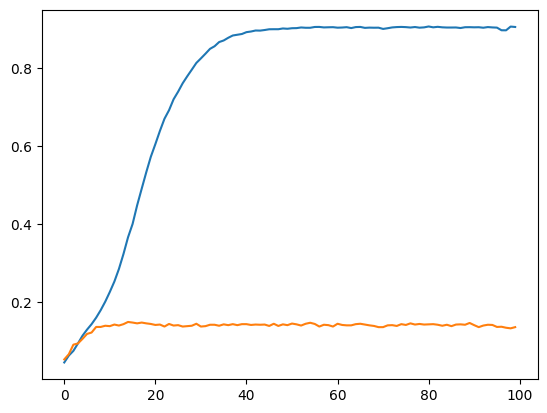

In [40]:
# Checking performance 

import seaborn as sns

sns.lineplot(history.history["accuracy"])
sns.lineplot(history.history["val_accuracy"])

<Axes: >

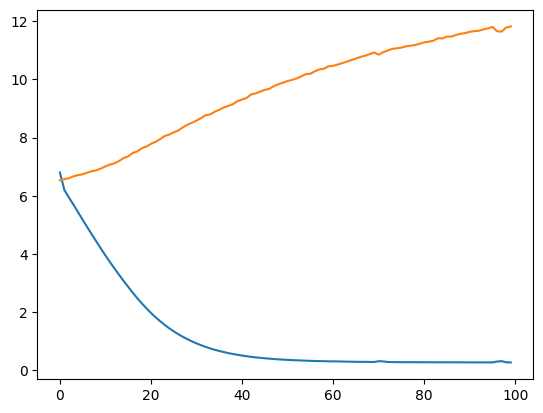

In [41]:
sns.lineplot(history.history["loss"])
sns.lineplot(history.history["val_loss"])

In [43]:
# Nvm it went to overfitting hell - gotta try to improve

### Methods to improve performance
- More data
- Hyperparameter tuning
- Adding more LSTM layers - stacked LSTM
- Advanced architectures - Stacked LSTM, Bidirectional LSTM, Transformers, etc

In [45]:
model.save("model.keras")

In [47]:
from tensorflow.keras.models import load_model

model = load_model("model.keras")

In [ ]:
# prediction

# let us first see for a single word

import numpy as np

input_words = ["what", "hello", "i", "yayy"]

for input_word in input_words: 
  tokenized_text = tokenizer.texts_to_sequences([input_word])[0]

  if not tokenized_text or not tokenized_text[0]:       # Check if tokenized_text is empty 
  # (happens when data unseen by tokenizer during fit  appears)
  # can fix during fit itself but too lazy to do now
        print(f"Input: {input_word}, Output: <UNK>")    # Handle unknown words
        continue
  
  padded_sequence = pad_sequences([tokenized_text], maxlen=max_len, padding="pre")
  y_pred = model.predict(padded_sequence)     # will give us a num_words length vector
  word_index = np.argmax(y_pred)              # max probability

  for word, index in tokenizer.word_index.items():
    if index == word_index:
      print(f"Input: {input_word}, Output: {word}")

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=int32)
  • training=False
  • mask=None

In [61]:
# let us try to predict multiple words 

text = "what"       # starting word

for i in range(10):   # 10 words will be predicted - the above procecss only running for 10 times
  tokenized_text = tokenizer.texts_to_sequences([text])
  padded_sequence = pad_sequences([tokenized_text], maxlen=max_len, padding="pre")
  y_pred = model.predict(padded_sequence)     # will give us a num_words length vector
  word_index = np.argmax(y_pred)              # max probability

  for word, index in tokenizer.word_index.items():
    if index == word_index:
      text = text + " " + word
      print(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
what do


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_7_1/Cast:0", shape=(1, 52, None), dtype=float32). Expected shape (None, 51), but input has incompatible shape (1, 52, None)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 52, None), dtype=int32)
  • training=False
  • mask=None